# 03 - Évaluation et Export

Ce notebook permet d'évaluer les performances du modèle et de l'exporter pour un déploiement mobile.

In [1]:
import torch
import numpy as np
import sys
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

sys.path.append('../src')
from model import CurlClassifier
from utils import load_dataset
from export_mobile import export_to_torchscript, export_quantized_model

## 1. Chargement des données et du modèle

In [2]:
base_path = '../data'
X, y = load_dataset(base_path)
X_torch = torch.tensor(np.transpose(X, (0, 2, 1)), dtype=torch.float32)

model = CurlClassifier()
model.load_state_dict(torch.load('../models_saved/curl_classifier.pth'))
model.eval()

CurlClassifier(
  (conv1): Conv1d(6, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=1600, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

## 2. Inférence et Matrice de Confusion

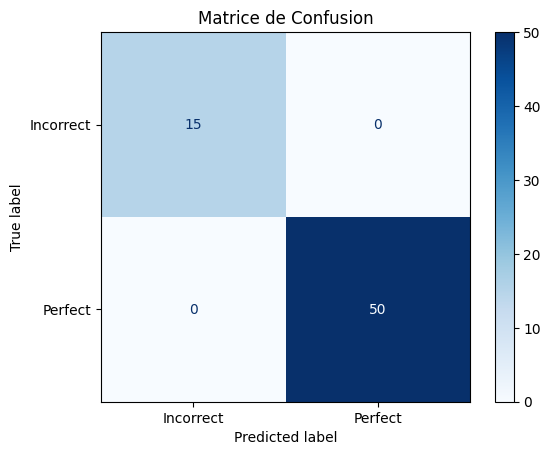

              precision    recall  f1-score   support

   Incorrect       1.00      1.00      1.00        15
     Perfect       1.00      1.00      1.00        50

    accuracy                           1.00        65
   macro avg       1.00      1.00      1.00        65
weighted avg       1.00      1.00      1.00        65



In [3]:
with torch.no_grad():
    outputs = model(X_torch)
    predictions = torch.argmax(outputs, dim=1).numpy()

cm = confusion_matrix(y, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Incorrect', 'Perfect'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de Confusion")
plt.show()

print(classification_report(y, predictions, target_names=['Incorrect', 'Perfect']))

## 3. Export Mobile

Conversion vers TorchScript et Quantification INT8.

In [4]:
export_to_torchscript(model, '../models_saved/curl_classifier_scripted.pt')
export_quantized_model(model, '../models_saved/curl_classifier_quant.pth')

print("Exports terminés.")

Model exported to TorchScript: ../models_saved/curl_classifier_scripted.pt
Quantized model state dict saved: ../models_saved/curl_classifier_quant.pth
Exports terminés.
